In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# url_2015 = "https://co2cars.apps.eea.europa.eu/tools/download?download_query=http://co2cars.apps.eea.europa.eu/?source={"track_total_hits":true,"query":{"bool":{"must":[{"constant_score":{"filter":{"bool":{"must":[{"bool":{"should":[{"term":{"year":2015}}]}},{"bool":{"should":[{"term":{"scStatus":"Final"}}]}}]}}}}]}},"display_type":"tabular"}&download_format=csv"
df = pd.read_csv(r'../data/raw/eu/CO2_passenger_cars_v12.csv', sep=None,
    engine="python",
    encoding="latin1",
)

# Preview top rows and summary stats
print("Shape:", df.shape)
df.info()
df.head()

Shape: (440645, 26)
<class 'pandas.DataFrame'>
RangeIndex: 440645 entries, 0 to 440644
Data columns (total 26 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   ï»¿id      440645 non-null  int64  
 1   MS         440645 non-null  str    
 2   MP         382812 non-null  str    
 3   Mh         440645 non-null  str    
 4   Man        440645 non-null  str    
 5   MMS        416338 non-null  str    
 6   TAN        428046 non-null  str    
 7   T          437911 non-null  str    
 8   Va         434992 non-null  str    
 9   Ve         426616 non-null  str    
 10  Mk         433711 non-null  str    
 11  Cn         439785 non-null  str    
 12  Ct         440642 non-null  str    
 13  r          440645 non-null  int64  
 14  e (g/km)   439848 non-null  float64
 15  m (kg)     440431 non-null  float64
 16  w (mm)     429822 non-null  float64
 17  at1 (mm)   430714 non-null  float64
 18  at2 (mm)   414935 non-null  float64
 19  Ft         440

,ï»¿id,MS,MP,Mh,Man,MMS,TAN,T,Va,Ve,...,w (mm),at1 (mm),at2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),It,Er (g/km)
0,346261,LU,VW GROUP PC,VOLKSWAGEN,VOLKSWAGEN AG,VOLKSWAGEN AG,E1*2007/46*0623*09,AU,AC4CRBCX0,FD6FD6D9004N7MJOMLVR2,...,2620.0,1527.0,1496.0,DIESEL,M,1968.0,110.0,NaN,NaN,NaN
1,346262,LU,VW GROUP PC,VOLKSWAGEN,VOLKSWAGEN AG,VOLKSWAGEN AG,E1*2007/46*0623*17,AU,GAC4CHHBX0,FD6FD6D9011S7MMON1ML71VR2,...,2626.0,1527.0,1496.0,PETROL,M,1984.0,162.0,NaN,NaN,NaN
2,346263,LU,VW GROUP PC,VOLKSWAGEN,VOLKSWAGEN AG,VOLKSWAGEN AG,E1*2001/116*0356*17,2EC2,KN4D1350N,MEC24VD9,...,3665.0,1710.0,1716.0,DIESEL,M,1968.0,120.0,NaN,NaN,NaN
3,346264,LU,VW GROUP PC,VOLKSWAGEN,VOLKSWAGEN AG,VOLKSWAGEN AG,E1*2007/46*0539*13,16,AECTHDX0,FD7FD7AM006N7MJVIVR0,...,2538.0,1570.0,1548.0,PETROL,M,1390.0,118.0,NaN,NaN,NaN
4,346265,LU,VW GROUP PC,VOLKSWAGEN,VOLKSWAGEN AG,VOLKSWAGEN AG,E1*2007/46*0539*14,16,ABCFFBX0,FD6FD62E018N7MJVIVR0,...,2524.0,1570.0,1546.0,DIESEL,M,1968.0,103.0,NaN,NaN,NaN


In [3]:
# 1. Filter the DataFrame for France ('FR')
df_fr = df[df["MS"] == "FR"].copy()

# 2. Reset the index 
df_fr.reset_index(drop=True, inplace=True)

# 3. Check the new shape and confirm
print("Filtered France Dataset Shape:", df_fr.shape)
print("Member States present:", df_fr["MS"].unique())

display(df_fr.head())

Filtered France Dataset Shape: (28051, 26)
Member States present: <StringArray>
['FR']
Length: 1, dtype: str


,ï»¿id,MS,MP,Mh,Man,MMS,TAN,T,Va,Ve,...,w (mm),at1 (mm),at2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),It,Er (g/km)
0,221520,FR,DAIMLER AG,DAIMLER AG,DAIMLER AG,DAIMLER AG,e1*2001/116*0335*28,221,P37VP0,CZAAB404,...,2945.0,1635.0,1633.0,Petrol,M,4663.0,335.0,NaN,NaN,NaN
1,221522,FR,DAIMLER AG,DAIMLER AG,DAIMLER AG,DAIMLER AG,e1*2001/116*0335*28,221,P37VP0,CZAAB424,...,2945.0,1631.0,1644.0,Petrol,M,4663.0,335.0,NaN,NaN,NaN
2,221573,FR,DAIMLER AG,DAIMLER AG,DAIMLER AG,DAIMLER AG,e1*2001/116*0335*29,221,P37VP0,CZAAB404,...,2945.0,1635.0,1633.0,Petrol,M,4663.0,335.0,NaN,NaN,NaN
3,221575,FR,DAIMLER AG,DAIMLER AG,DAIMLER AG,DAIMLER AG,e1*2001/116*0335*29,221,P37VP0,CZAAB424,...,2945.0,1631.0,1644.0,Petrol,M,4663.0,335.0,NaN,NaN,NaN
4,221597,FR,DAIMLER AG,DAIMLER AG,DAIMLER AG,DAIMLER AG,e1*2001/116*0335*31,221,P37VP0,CZAA0424,...,2945.0,1631.0,1644.0,Petrol,M,4663.0,335.0,NaN,NaN,NaN


In [4]:
df_fr.info()

<class 'pandas.DataFrame'>
RangeIndex: 28051 entries, 0 to 28050
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ï»¿id      28051 non-null  int64  
 1   MS         28051 non-null  str    
 2   MP         24245 non-null  str    
 3   Mh         28051 non-null  str    
 4   Man        28051 non-null  str    
 5   MMS        28051 non-null  str    
 6   TAN        28051 non-null  str    
 7   T          27871 non-null  str    
 8   Va         28049 non-null  str    
 9   Ve         28050 non-null  str    
 10  Mk         28051 non-null  str    
 11  Cn         28051 non-null  str    
 12  Ct         28051 non-null  str    
 13  r          28051 non-null  int64  
 14  e (g/km)   28051 non-null  float64
 15  m (kg)     28051 non-null  float64
 16  w (mm)     28051 non-null  float64
 17  at1 (mm)   28051 non-null  float64
 18  at2 (mm)   26570 non-null  float64
 19  Ft         28051 non-null  str    
 20  Fm         28051 

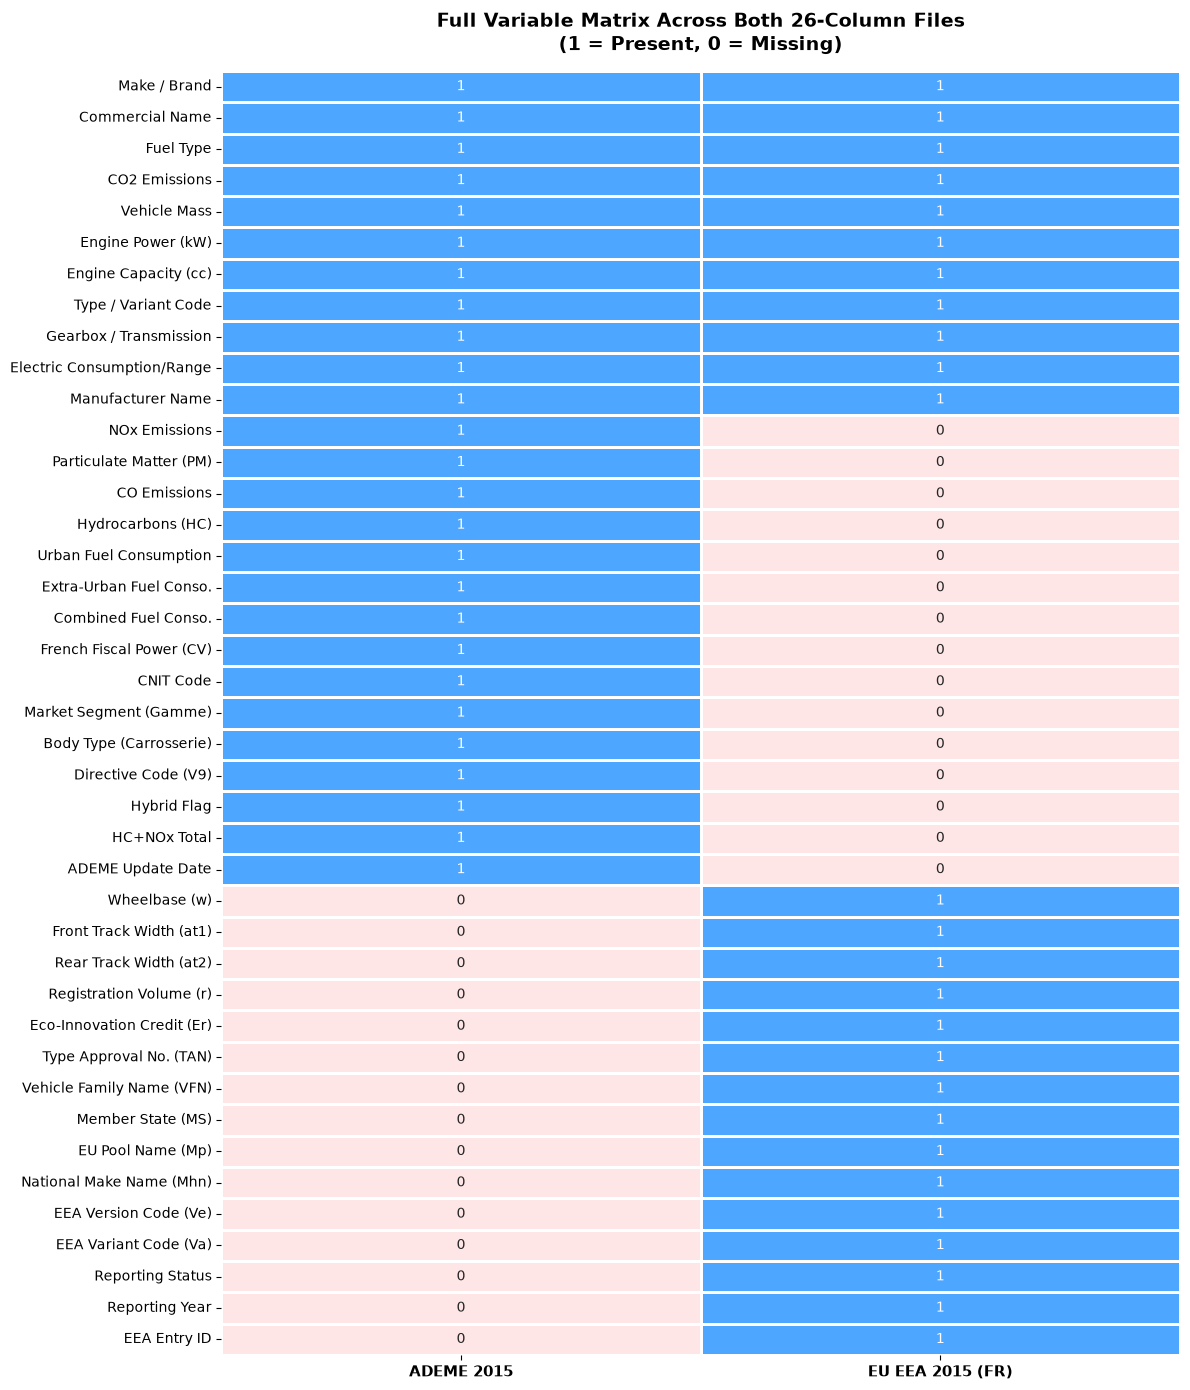

<Figure size 640x480 with 0 Axes>


Approach A completed successfully. Outputs saved to: ../reports/figures/comparison_results


In [5]:
#to generate an exact 26-column coverage plot to show every single column in the presentation,
# Complete 26-Variable comparison mapping
mapping_dict = {
    # Shared / Equivalent Concepts (11)
    "Make / Brand": (1, 1),
    "Commercial Name": (1, 1),
    "Fuel Type": (1, 1),
    "CO2 Emissions": (1, 1),
    "Vehicle Mass": (1, 1),
    "Engine Power (kW)": (1, 1),
    "Engine Capacity (cc)": (1, 1),
    "Type / Variant Code": (1, 1),
    "Gearbox / Transmission": (1, 1),
    "Electric Consumption/Range": (1, 1),
    "Manufacturer Name": (1, 1),
    # ADEME Exclusive (15)
    "NOx Emissions": (1, 0),
    "Particulate Matter (PM)": (1, 0),
    "CO Emissions": (1, 0),
    "Hydrocarbons (HC)": (1, 0),
    "Urban Fuel Consumption": (1, 0),
    "Extra-Urban Fuel Conso.": (1, 0),
    "Combined Fuel Conso.": (1, 0),
    "French Fiscal Power (CV)": (1, 0),
    "CNIT Code": (1, 0),
    "Market Segment (Gamme)": (1, 0),
    "Body Type (Carrosserie)": (1, 0),
    "Directive Code (V9)": (1, 0),
    "Hybrid Flag": (1, 0),
    "HC+NOx Total": (1, 0),
    "ADEME Update Date": (1, 0),
    # EEA Exclusive (15)
    "Wheelbase (w)": (0, 1),
    "Front Track Width (at1)": (0, 1),
    "Rear Track Width (at2)": (0, 1),
    "Registration Volume (r)": (0, 1),
    "Eco-Innovation Credit (Er)": (0, 1),
    "Type Approval No. (TAN)": (0, 1),
    "Vehicle Family Name (VFN)": (0, 1),
    "Member State (MS)": (0, 1),
    "EU Pool Name (Mp)": (0, 1),
    "National Make Name (Mhn)": (0, 1),
    "EEA Version Code (Ve)": (0, 1),
    "EEA Variant Code (Va)": (0, 1),
    "Reporting Status": (0, 1),
    "Reporting Year": (0, 1),
    "EEA Entry ID": (0, 1),
}

# Create DataFrame
df_all_vars = pd.DataFrame(
    [v[0] for v in mapping_dict.values()],
    index=mapping_dict.keys(),
    columns=["ADEME 2015"],
)
df_all_vars["EU EEA 2015 (FR)"] = [v[1] for v in mapping_dict.values()]

# Plot Full Heatmap
plt.figure(figsize=(12, 14))
sns.heatmap(
    df_all_vars,
    annot=True,
    cbar=False,
    cmap=["#ffe6e6", "#4da6ff"],
    linewidths=1,
    linecolor="white",
    fmt="d",
)

plt.title(
    "Full Variable Matrix Across Both 26-Column Files\n(1 = Present, 0 = Missing)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

output_dir = (r"../reports/figures/comparison_results")
os.makedirs(output_dir, exist_ok=True)
plt.yticks(fontsize=10)
plt.xticks(fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig(
    os.path.join(output_dir, "approach_a_co2_distribution_comparison.png")
)

plt.show()

print(
    f"\nApproach A completed successfully. Outputs saved to: {output_dir}"
)

In [6]:
# Exploration of similarities between the information in the columns ADEME v/s EEA
# 
# 1. File paths and loading datasets
# 
ademe_path = r"../data/raw/france/2015.csv"
eea_path = r"../data/processed/eu/CO2_passenger_cars_v12.csv"

output_dir = (r"../reports/figures/comparison_results")
os.makedirs(output_dir, exist_ok=True)

print("--- Loading Datasets ---")

# Load ADEME (French National Data)
df_ademe = pd.read_csv(ademe_path, sep=";", encoding="latin1", low_memory=False)

# Load EU EEA with robust separator fallback and filter for France (df_fr)
try:
    df_eea_raw = pd.read_csv(
        eea_path,
        sep="\t",
        encoding="latin1",
        on_bad_lines="skip",
        low_memory=False,
    )
    if "MS" not in df_eea_raw.columns and len(df_eea_raw.columns) == 1:
        df_eea_raw = pd.read_csv(
            eea_path,
            sep=",",
            encoding="latin1",
            on_bad_lines="skip",
            low_memory=False,
        )
except Exception:
    df_eea_raw = pd.read_csv(
        eea_path,
        sep=",",
        encoding="latin1",
        on_bad_lines="skip",
        low_memory=False,
    )

# Clean BOM symbols and column whitespace
df_eea_raw.columns = df_eea_raw.columns.str.replace("ï»¿", "").str.strip()

# Extract France subset
if "MS" in df_eea_raw.columns:
    df_fr = df_eea_raw[df_eea_raw["MS"] == "FR"].copy().reset_index(drop=True)
else:
    raise KeyError(
        f"Could not find 'MS' column. Found: {list(df_eea_raw.columns[:5])}"
    )

print(f"ADEME 2015 Shape: {df_ademe.shape}")
print(f"EU EEA 2015 France Subset (df_fr) Shape: {df_fr.shape}\n")


--- Loading Datasets ---
ADEME 2015 Shape: (20880, 26)
EU EEA 2015 France Subset (df_fr) Shape: (28051, 26)



In [7]:
#The EU EEA dataset captures significantly more records (~28,051 registrations) compared to ADEME (~20,824 records). 
#This represents a ~34.7% larger sample size, 
#offering a more representative slice of actual sales/registrations across France in 2015.

In [8]:
# 
# 2. data cleaning and standarization
# 
# Ensure ADEME numeric types (handle commas if string)
for col in ["puiss_max", "co2_mixte", "masse_ordma_min"]:
    if df_ademe[col].dtype == "object":
        df_ademe[col] = (
            df_ademe[col]
            .astype(str)
            .str.replace(",", ".")
            .replace("nan", np.nan)
        )
        df_ademe[col] = pd.to_numeric(df_ademe[col], errors="coerce")

# Fuel mapping to standardize fuel codes
fuel_map_ademe = {
    "ES": "PETROL",
    "GO": "DIESEL",
    "EL": "ELECTRIC",
    "EH": "HYBRID_PETROL",
    "GH": "HYBRID_DIESEL",
}
df_ademe["fuel_std"] = (
    df_ademe["energ"].map(fuel_map_ademe).fillna("OTHER/HYBRID")
)
df_fr["fuel_std"] = (
    df_fr["Ft"].astype(str).str.upper().str.strip().fillna("OTHER/HYBRID")
)

# Extract standardized columns
ademe_num = df_ademe[["co2_mixte", "puiss_max", "masse_ordma_min"]].rename(
    columns={
        "co2_mixte": "CO2_g_km",
        "puiss_max": "Power_kW",
        "masse_ordma_min": "Mass_kg",
    }
)

eea_num = df_fr[["e (g/km)", "ep (KW)", "m (kg)"]].rename(
    columns={"e (g/km)": "CO2_g_km", "ep (KW)": "Power_kW", "m (kg)": "Mass_kg"}
)



In [9]:
# 
# 3. statistical comparison table
# 
def get_stats_summary(df, dataset_name):
    summary = []
    for col in df.columns:
        data = df[col].dropna()
        summary.append(
            {
                "Dataset": dataset_name,
                "Metric": col,
                "Count": len(data),
                "Mean": round(data.mean(), 2),
                "Std": round(data.std(), 2),
                "Median": round(data.median(), 2),
                "Min": round(data.min(), 2),
                "Max": round(data.max(), 2),
                "Skewness": round(stats.skew(data), 2),
            }
        )
    return pd.DataFrame(summary)


stats_ademe = get_stats_summary(ademe_num, "ADEME 2015 (UTAC)")
stats_eea = get_stats_summary(eea_num, "EU EEA 2015 (FR)")

comp_stats_df = pd.concat([stats_ademe, stats_eea], ignore_index=True)
print(" NUMERICAL DISTRIBUTION COMPARISON ")
print(comp_stats_df.to_string(index=False))

# Export statistics to Excel
comp_stats_df.to_excel(
    os.path.join(output_dir, "approach_a_numerical_comparison.xlsx"),
    index=False,
)

# 
# 4. categorical distribution comparison
# 
print("\nFUEL TYPE DISTRIBUTION (%) ")
fuel_ademe_pct = (
    df_ademe["fuel_std"].value_counts(normalize=True) * 100
).rename("ADEME %")
fuel_eea_pct = (df_fr["fuel_std"].value_counts(normalize=True) * 100).rename(
    "EU_EEA_FR %"
)
fuel_comp = (
    pd.concat([fuel_ademe_pct, fuel_eea_pct], axis=1)
    .fillna(0)
    .round(2)
)
print(fuel_comp)



 NUMERICAL DISTRIBUTION COMPARISON 
          Dataset   Metric  Count    Mean    Std  Median   Min    Max  Skewness
ADEME 2015 (UTAC) CO2_g_km  20824  154.58  44.25   147.0  13.0  398.0      1.29
ADEME 2015 (UTAC) Power_kW  20824  146.09  80.11   120.0  28.0  585.0      2.07
ADEME 2015 (UTAC)  Mass_kg  20880 1810.56 371.92  1760.0 875.0 2765.0      0.34
 EU EEA 2015 (FR) CO2_g_km  28051  131.19  35.30   124.0   0.0  398.0      1.58
 EU EEA 2015 (FR) Power_kW  28044  118.08  59.54   105.0  24.0  585.0      2.40
 EU EEA 2015 (FR)  Mass_kg  28051 1521.12 300.50  1490.0 565.0 2857.0      0.70

FUEL TYPE DISTRIBUTION (%) 
                 ADEME %  EU_EEA_FR %
fuel_std                             
OTHER/HYBRID       100.0         0.00
DIESEL               0.0        60.38
PETROL               0.0        38.14
ELECTRIC             0.0         0.53
PETROL-ELECTRIC      0.0         0.50
LPG                  0.0         0.27
NG-BIOMETHANE        0.0         0.07
E85                  0.0         

In [10]:
#The ADEME dataset suffers from a mapping or coding failure, classifying 100% of vehicles into OTHER/HYBRID, 
#completely losing the distinction between Diesel, Petrol, and Electric models.
#####
#the EU EEA dataset provides granular fuel breakdowns (60.38% Diesel, 38.14% Petrol, 0.53% Electric, LPG, Flex-fuel, etc.), 
#which is essential for any powertrain-specific analysis.
####
#ADEME offers tailpipe pollutant data (NOx, PM, CO), 
#the EU EEA dataset provides crucial engineering and market dimensions missing entirely in ADEME
# Using the EU EEA dataset ensures alignment with EU-level regulatory frameworks and 
#fleet target monitoring (e.g., EC No 443/2009 standards)


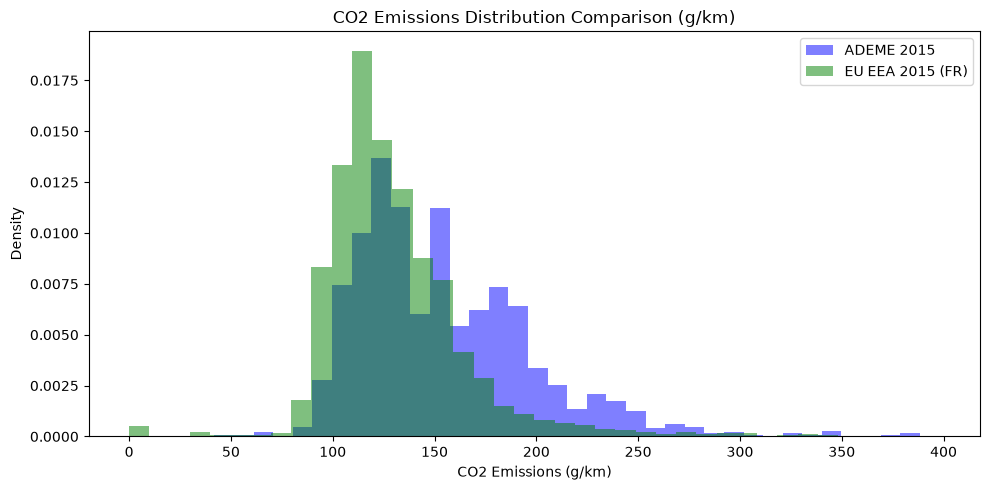


Approach A completed successfully. Outputs saved to: ../reports/figures/comparison_results


In [11]:
# 
# 5. visualization
# 
plt.figure(figsize=(10, 5))
plt.hist(
    ademe_num["CO2_g_km"].dropna(),
    bins=40,
    alpha=0.5,
    label="ADEME 2015",
    color="blue",
    density=True,
)
plt.hist(
    eea_num["CO2_g_km"].dropna(),
    bins=40,
    alpha=0.5,
    label="EU EEA 2015 (FR)",
    color="green",
    density=True,
)
plt.title("CO2 Emissions Distribution Comparison (g/km)")
plt.xlabel("CO2 Emissions (g/km)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "approach_a_co2_distribution_comparison_1.png")
)
#plt.close()

plt.show()
print(
    f"\nApproach A completed successfully. Outputs saved to: {output_dir}"
)

In [12]:
#The histogram compares the probability density distributions of CO2 emissions (g/km) 
#between ADEME 2015 (blue) and EU EEA 2015 - France (green)
#EU EEA displays a small spike at 0 g/km, capturing zero-emission battery electric vehicles
# About the electric vehicle. Renault Zoe: The top-selling EV in France (and Europe) in 2015
#ADEME has virtually no mass near zero, highlighting missing or misclassified 
#pure electric vehicle entries in that specific slice.